# Mental Health Dataset Preparation

## Objective

This notebook prepares the mental-health text dataset for traditional machine learning and BERT fine-tuning.

The main objectives are to:

- inspect the dataset structure,
- identify missing values,
- standardize class labels,
- detect duplicate texts,
- remove conflicting labels,
- analyze class distribution,
- create reproducible train, validation, and test sets,
- and save the processed datasets for model training.

## Target classes

The project focuses on four mental-health-related text classes:

1. Anxiety
2. Depression
3. Normal
4. Suicidal

> This project is intended for educational and research purposes. It is not a clinical diagnostic system.

In [1]:
# Loading libraries
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# Defining project routes
PROJECT_ROOT = Path("..")

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "mental_health_train_raw.csv"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Raw data path:", RAW_DATA_PATH)
print("Processed data directory:", PROCESSED_DATA_DIR)
print("Raw dataset exists:", RAW_DATA_PATH.exists())

Raw data path: ../data/raw/mental_health_train_raw.csv
Processed data directory: ../data/processed
Raw dataset exists: True


In [4]:
# Loading the dataset
df = pd.read_csv(RAW_DATA_PATH)

print("Dataset successfully loaded.")
print("Dataset shape:", df.shape)

Dataset successfully loaded.
Dataset shape: (49612, 3)


In [5]:
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

,Unique_ID,text,status
0,0.0,oh my gosh,Anxiety
1,1.0,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2.0,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3.0,I've shifted my focus to something else but I'...,Anxiety
4,4.0,"I'm restless and restless, it's been a month n...",Anxiety



Column names:
['Unique_ID', 'text', 'status']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 49612 entries, 0 to 49611
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Unique_ID  40012 non-null  float64
 1   text       49612 non-null  str    
 2   status     49612 non-null  str    
dtypes: float64(1), str(2)
memory usage: 20.5 MB


In [11]:
df.sample()

,Unique_ID,text,status
49091,NaN,"https://imgur.com/a/GsApb4VAs a male, I'm fucked",Suicidal


In [12]:
# Key data quality summary
data_quality_summary = pd.DataFrame(
    {
        "data_type": df.dtypes.astype(str),
        "missing_count": df.isna().sum(),
        "missing_percentage": (df.isna().mean() * 100).round(2),
        "unique_values": df.nunique(dropna=False),
    }
)

display(data_quality_summary)

,data_type,missing_count,missing_percentage,unique_values
Unique_ID,float64,9600,19.35,40013
text,str,0,0.00,48945
status,str,0,0.00,4


In [13]:
# Column validation
# (I validate the expected schema before preprocessing so that the pipeline fails early if required columns are missing)
required_columns = {"text", "status"}

missing_columns = required_columns.difference(df.columns)

if missing_columns:
    raise ValueError(f"Required columns are missing: {missing_columns}")

print("Required columns are available:", required_columns)

Required columns are available: {'text', 'status'}


In [19]:
df["Unique_ID"].head(20)

0      0.0
1      1.0
2      2.0
3      3.0
4      4.0
5      5.0
6      6.0
7      7.0
8      8.0
9      9.0
10    10.0
11    11.0
12    12.0
13    13.0
14    14.0
15    15.0
16    16.0
17    17.0
18    18.0
19    19.0
Name: Unique_ID, dtype: float64

In [20]:
print(df["Unique_ID"].nunique())

40012


In [21]:
print(df["Unique_ID"].isna().sum())

9600


In [22]:
print("First 20 values:")
display(df["Unique_ID"].head(20))

print("\nNumber of unique non-missing IDs:")
print(df["Unique_ID"].nunique())

print("\nNumber of missing IDs:")
print(df["Unique_ID"].isna().sum())

print("\nNumber of duplicated non-missing IDs:")
print(df["Unique_ID"].dropna().duplicated().sum())

First 20 values:


0      0.0
1      1.0
2      2.0
3      3.0
4      4.0
5      5.0
6      6.0
7      7.0
8      8.0
9      9.0
10    10.0
11    11.0
12    12.0
13    13.0
14    14.0
15    15.0
16    16.0
17    17.0
18    18.0
19    19.0
Name: Unique_ID, dtype: float64


Number of unique non-missing IDs:
40012

Number of missing IDs:
9600

Number of duplicated non-missing IDs:
0


## Remove Non-Informative Identifier

The dataset contains a `Unique_ID` column. This column is only used as an identifier and does not provide any linguistic or semantic information for text classification.

Additionally, approximately 19% of the identifier values are missing.

Therefore, the `Unique_ID` column is removed before preprocessing.

In [23]:
# Remove identifier column
df = df.drop(columns=["Unique_ID"])

print("Remaining columns:")
print(df.columns.tolist())

print("\nDataset shape:")
print(df.shape)

Remaining columns:
['text', 'status']

Dataset shape:
(49612, 2)


## Standardize Class Labels

Before training the model, the class labels are standardized by removing leading and trailing whitespace and converting all labels to title case.

This helps prevent inconsistencies caused by formatting differences.

In [24]:
print("Labels before cleaning:")
print(df["status"].unique())

df["status"] = df["status"].str.strip().str.title()

print("\nLabels after cleaning:")
print(df["status"].unique())

Labels before cleaning:
<ArrowStringArray>
['Anxiety', 'Normal', 'Depression', 'Suicidal']
Length: 4, dtype: str

Labels after cleaning:
<ArrowStringArray>
['Anxiety', 'Normal', 'Depression', 'Suicidal']
Length: 4, dtype: str


In [25]:
VALID_LABELS = {
    "Anxiety",
    "Depression",
    "Normal",
    "Suicidal",
}

invalid_labels = set(df["status"].unique()) - VALID_LABELS

print("Invalid labels:", invalid_labels)

Invalid labels: set()


### Observation

After standardization, all class labels remain valid. No unexpected or misspelled labels were detected.

This indicates that the dataset labels are already well standardized.

## Duplicate Text Analysis

Duplicate text entries can introduce bias during model training because the model may repeatedly observe identical examples.

Therefore, duplicate texts are identified before training.

In [26]:
duplicate_count = df.duplicated(subset=["text"]).sum()

duplicate_percentage = (duplicate_count / len(df)) * 100

print(f"Duplicate texts: {duplicate_count:,}")

print(f"Percentage: {duplicate_percentage:.2f}%")

Duplicate texts: 667
Percentage: 1.34%


In [27]:
duplicate_examples = df[df.duplicated(subset=["text"], keep=False)].sort_values("text")

display(duplicate_examples.head(20))

,text,status
39233,"""Buy Friends"" comment? My mother doesn't have ...",Anxiety
39998,"""Buy Friends"" comment? My mother doesn't have ...",Anxiety
18,"""No regrets or grudges/angry at things that ha...",Anxiety
96,"""No regrets or grudges/angry at things that ha...",Anxiety
307,"""No regrets or grudges/angry at things that ha...",Anxiety
448,"""No regrets or grudges/angry at things that ha...",Anxiety
500,"""No regrets or grudges/angry at things that ha...",Anxiety
39218,.5 mg lorazepam and drinking If I take .5 mg o...,Anxiety
39983,.5 mg lorazepam and drinking If I take .5 mg o...,Anxiety
39161,10 years of Celexa/Lexapro and thinking of mak...,Anxiety


In [70]:
remaining_duplicates = df.duplicated(subset=["text"]).sum()

print("Dataset shape after duplicate removal:", df.shape)
print("Remaining duplicate texts:", remaining_duplicates)

assert remaining_duplicates == 0

Dataset shape after duplicate removal: (48935, 4)
Remaining duplicate texts: 0


## Conflicting Label Analysis

A duplicate text is not necessarily problematic if it always belongs to the same class.

However, if identical texts are assigned different class labels, they introduce contradictory supervision and should be removed before training.

In [29]:
label_conflicts = df.groupby("text")["status"].nunique()

conflicting_texts = label_conflicts[label_conflicts > 1].index

print("Number of conflicting texts:")
print(len(conflicting_texts))

Number of conflicting texts:
10


In [30]:
conflict_examples = df[df["text"].isin(conflicting_texts)].sort_values("text")

display(conflict_examples.head(20))

,text,status
7637,"All this work, all this pressure that everyone...",Suicidal
7638,"All this work, all this pressure that everyone...",Depression
38296,Are my anti-depressants not working? I’ve (22F...,Depression
39033,Are my anti-depressants not working? I’ve (22F...,Depression
39194,Are my anti-depressants not working? I’ve (22F...,Anxiety
39959,Are my anti-depressants not working? I’ve (22F...,Anxiety
38755,"I cant function anymore, my cognitive abilitie...",Depression
39565,"I cant function anymore, my cognitive abilitie...",Anxiety
10984,I have been at home the past year... quite lit...,Suicidal
10989,I have been at home the past year... quite lit...,Depression


In [71]:
remaining_conflicts = df.groupby("text")["status"].nunique().gt(1).sum()

print("Remaining conflicting texts:", remaining_conflicts)

assert remaining_conflicts == 0

Remaining conflicting texts: 0


In [31]:
# I removed all conflicting examples because identical texts assigned to different labels introduce contradictory supervision.
#  Without external validation, there is no objective way to determine which label is correct.
conflict_examples = df[df["text"].isin(conflicting_texts)].sort_values("text")

display(conflict_examples)

,text,status
7637,"All this work, all this pressure that everyone...",Suicidal
7638,"All this work, all this pressure that everyone...",Depression
38296,Are my anti-depressants not working? I’ve (22F...,Depression
39033,Are my anti-depressants not working? I’ve (22F...,Depression
39194,Are my anti-depressants not working? I’ve (22F...,Anxiety
39959,Are my anti-depressants not working? I’ve (22F...,Anxiety
38755,"I cant function anymore, my cognitive abilitie...",Depression
39565,"I cant function anymore, my cognitive abilitie...",Anxiety
10984,I have been at home the past year... quite lit...,Suicidal
10989,I have been at home the past year... quite lit...,Depression


In [32]:
print("Dataset shape before removing conflicts:")
print(df.shape)

df = df[~df["text"].isin(conflicting_texts)].copy()

print("\nDataset shape after removing conflicts:")
print(df.shape)

Dataset shape before removing conflicts:
(49612, 2)

Dataset shape after removing conflicts:
(49588, 2)


In [35]:
# I removed the remaining duplicate texts
df = df.drop_duplicates(subset="text", keep="first").reset_index(drop=True)

In [37]:
df.shape

(48935, 2)

In [38]:
# print(df["text"].apply(lambda x: len(x.split())).max())

9684


## Text Statistics

Understanding the length of the text samples is important before training a language model.

In this section, we calculate:

- character count
- word count
- summary statistics

These statistics help us choose an appropriate maximum sequence length for BERT tokenization.

In [40]:
df["char_count"] = df["text"].str.len()

df["word_count"] = df["text"].str.split().str.len()

In [41]:
print("Character Statistics")

display(df["char_count"].describe())

Character Statistics


count    48935.000000
mean       400.232676
std        620.644518
min          7.000000
25%         74.000000
50%        243.000000
75%        559.000000
max      38785.000000
Name: char_count, dtype: float64

In [43]:
print("Word Statistics")

display(df["word_count"].describe())

Word Statistics


count    48935.000000
mean        78.450557
std        122.768124
min          1.000000
25%         14.000000
50%         47.000000
75%        110.000000
max       9684.000000
Name: word_count, dtype: float64

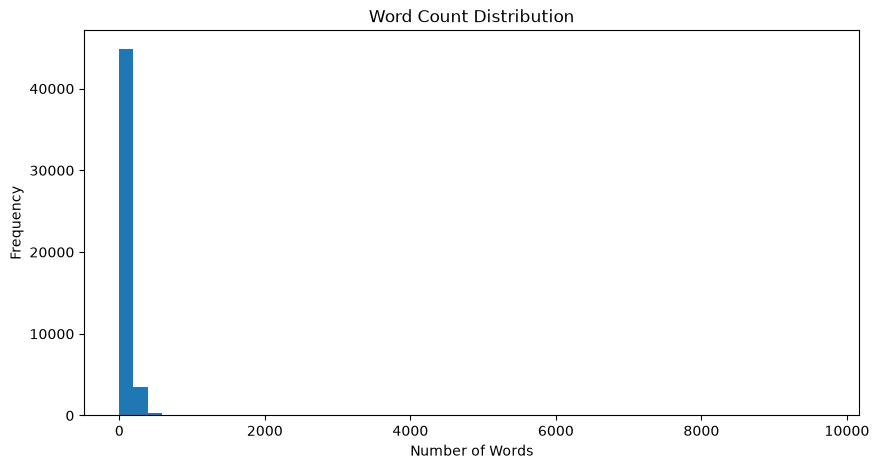

In [48]:
plt.figure(figsize=(10, 5))
plt.hist(df["word_count"], bins=50)
plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

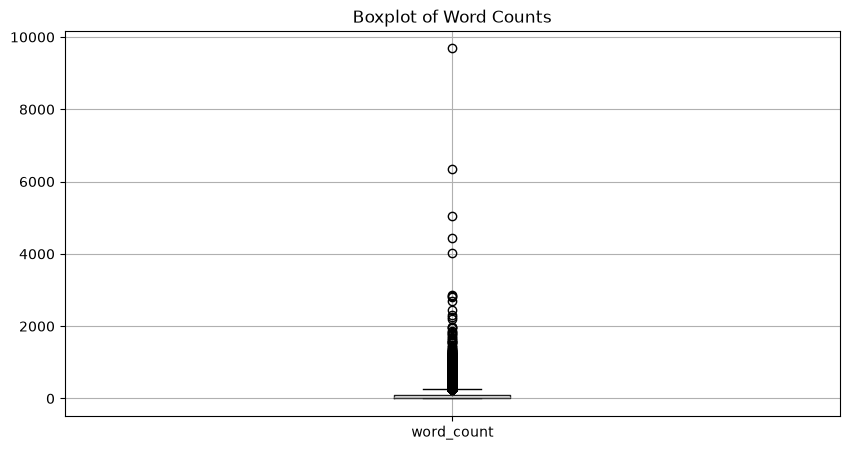

In [49]:
plt.figure(figsize=(10, 5))

df.boxplot(column="word_count")

plt.title("Boxplot of Word Counts")

plt.show()

In [50]:
print("=" * 60)
print("Character Statistics")
print("=" * 60)

display(df["char_count"].describe())

print()

print("=" * 60)
print("Word Statistics")
print("=" * 60)

display(df["word_count"].describe())

Character Statistics


count    48935.000000
mean       400.232676
std        620.644518
min          7.000000
25%         74.000000
50%        243.000000
75%        559.000000
max      38785.000000
Name: char_count, dtype: float64


Word Statistics


count    48935.000000
mean        78.450557
std        122.768124
min          1.000000
25%         14.000000
50%         47.000000
75%        110.000000
max       9684.000000
Name: word_count, dtype: float64

In [51]:
print(f"Average number of characters: {df['char_count'].mean():.2f}")

print(f"Average number of words: {df['word_count'].mean():.2f}")

print(f"Longest text (characters): {df['char_count'].max()}")

print(f"Longest text (words): {df['word_count'].max()}")

Average number of characters: 400.23
Average number of words: 78.45
Longest text (characters): 38785
Longest text (words): 9684


In [52]:
# Top 10 longest texts
longest_texts = df.sort_values(by="word_count", ascending=False)[
    ["status", "word_count", "char_count", "text"]
].head(10)

display(longest_texts)

,status,word_count,char_count,text
42223,Suicidal,9684,38738,Get out of my head.Get out of my head. Get out...
41970,Normal,6353,38785,What do you guys think about my book? \n the b...
42262,Normal,5058,17736,"Ahem, excuse me while I rehearse the speech I’..."
44565,Depression,4426,23386,this is a long story but i'm going to be as ho...
41341,Depression,4038,20717,edit: due to many hurtful comments and numerou...
47397,Suicidal,2854,15149,i'm tiredive thought about dying and killing ...
42728,Suicidal,2825,14527,The night that changed my life forever. (TW: A...
44718,Anxiety,2809,14774,"hi, first of all, let me introduce myself. i'm..."
47616,Depression,2700,10124,i hate my life i hate my life i hate my life i...
43143,Suicidal,2454,12983,Am I suicidal?Sorry if this is the wrong place...


In [53]:
longest = df.loc[df["word_count"].idxmax()]

print("Label:", longest["status"])
print("Word count:", longest["word_count"])
print("Character count:", longest["char_count"])

print("\nFirst 2000 characters:\n")
print(longest["text"][:2000])

Label: Suicidal
Word count: 9684
Character count: 38738

First 2000 characters:

Get out of my head.Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. Get out of my head. 

# Class Distribution

Understanding the class distribution is essential before training a classification model.

If the dataset is imbalanced, accuracy alone may become misleading.

Therefore, the distribution of the four mental health classes is examined before model training.

In [54]:
class_counts = df["status"].value_counts().sort_index()

display(class_counts)

status
Anxiety        5325
Depression    14259
Normal        18151
Suicidal      11200
Name: count, dtype: int64

In [57]:
class_percentages = (
    df["status"].value_counts(normalize=True).sort_index() * 100
).round(2)

display(class_percentages)

status
Anxiety       10.88
Depression    29.14
Normal        37.09
Suicidal      22.89
Name: proportion, dtype: float64

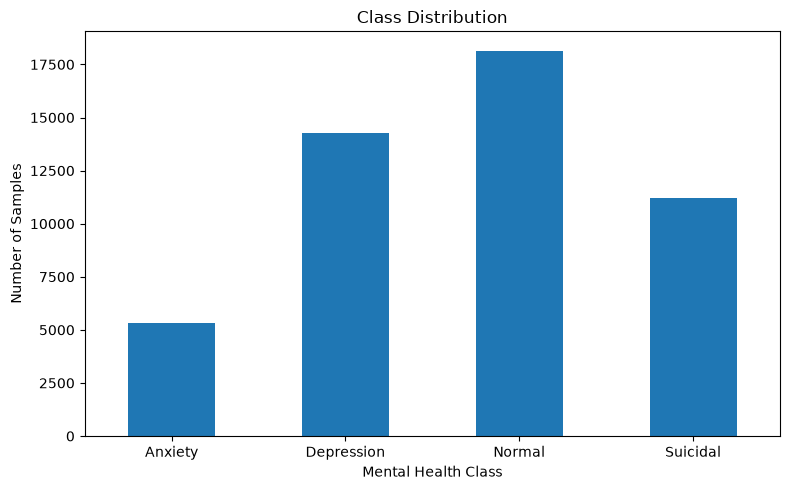

In [58]:
plt.figure(figsize=(8, 5))

class_counts.plot(kind="bar")

plt.title("Class Distribution")

plt.xlabel("Mental Health Class")

plt.ylabel("Number of Samples")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [59]:
distribution_table = pd.DataFrame(
    {"Count": class_counts, "Percentage": class_percentages}
)

display(distribution_table)

,Count,Percentage
status,,
Anxiety,5325,10.88
Depression,14259,29.14
Normal,18151,37.09
Suicidal,11200,22.89


In [60]:
from sklearn.model_selection import train_test_split

In [65]:
# First split: Train (70%) and Temp (30%)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["status"],
    random_state=42,
)

# Second split: Validation (15%) and Test (15%)
validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["status"],
    random_state=42,
)

In [62]:
print("Training set:", train_df.shape)
print("Validation set:", validation_df.shape)
print("Test set:", test_df.shape)

Training set: (34254, 4)
Validation set: (7340, 4)
Test set: (7341, 4)


In [64]:
print(train_df["status"].value_counts(normalize=True))

print(validation_df["status"].value_counts(normalize=True))

print(test_df["status"].value_counts(normalize=True))

status
Normal        0.370935
Depression    0.291382
Suicidal      0.228878
Anxiety       0.108805
Name: proportion, dtype: float64
status
Normal        0.370845
Depression    0.291417
Suicidal      0.228883
Anxiety       0.108856
Name: proportion, dtype: float64
status
Normal        0.370930
Depression    0.291377
Suicidal      0.228852
Anxiety       0.108841
Name: proportion, dtype: float64


In [68]:
OUTPUT_COLUMNS = ["text", "status"]

train_df = train_df[OUTPUT_COLUMNS].reset_index(drop=True)
validation_df = validation_df[OUTPUT_COLUMNS].reset_index(drop=True)
test_df = test_df[OUTPUT_COLUMNS].reset_index(drop=True)

In [69]:
train_df.to_csv(
    PROCESSED_DATA_DIR / "train.csv",
    index=False,
)

validation_df.to_csv(
    PROCESSED_DATA_DIR / "validation.csv",
    index=False,
)

test_df.to_csv(
    PROCESSED_DATA_DIR / "test.csv",
    index=False,
)

print("Processed datasets saved successfully.")

Processed datasets saved successfully.


In [67]:
print(train_df.head())

print(validation_df.head())

print(test_df.head())

                                                    text      status  \
30639  @harbars managed to fix broken moss in 2 min a...      Normal   
4631   It's 3 o'clock, the call to prayer for the mor...      Normal   
30671  @ShaileeMody thats a killing smile.. i m flatt...      Normal   
44508  How to stop waking up feeling suicidal?For the...    Suicidal   
17687  I know some people that want to live and turn ...  Depression   

       char_count  word_count  
30639          77          15  
4631           83          15  
30671          53           8  
44508         236          45  
17687         437          95  
                                                    text      status  \
1745              Lucky to have a special voting account      Normal   
18671  I do not know how to deal with feeling and and...  Depression   
33287  theekween it help with depression anxiety hear...  Depression   
14736  Background: I have major depression that was r...  Depression   
44927  title sa

# Key Takeaways

In this notebook, the raw dataset was transformed into a clean and reliable dataset for machine learning.

Main preprocessing steps included:

- Removing a non-informative identifier
- Standardizing class labels
- Removing conflicting labels
- Removing duplicate texts
- Exploring text characteristics
- Analyzing class distribution
- Creating stratified train, validation, and test sets

The processed datasets are now ready for BERT tokenization and model training.